<a href="https://colab.research.google.com/github/Code-amar/Python-Case-Study-/blob/main/Python_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# importing necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
import warnings
warnings.filterwarnings( "ignore")

In [24]:
car_df = pd.read_csv('/content/CarFeatures.csv')
car_df

,Make,Fuel Type,Aspiration,Number of Doors,Body Style,Drive Wheels,Engine Location,Number of Cylinders,Wheel Base,Length,Width,Height,Curb Weight,Engine Size,Horsepower,City MPG,Highway MPG,Price
0,Toyota,Diesel,Std,Two,Convertible,Fwd,Front,Twelve,95.1,175.9,60.6,59.4,1758,252,279,40,41,5272
1,Mitsubishi,Diesel,Std,Four,Convertible,Fwd,Rear,Four,91.7,153.9,60.5,55.1,1887,95,150,32,42,31393
2,Chevrolet,Gas,Turbo,Four,Hatchback,Rwd,Front,Two,116.2,203.5,65.3,58.5,3815,231,129,13,41,40450
3,Mitsubishi,Gas,Turbo,Four,Hatchback,Fwd,Front,Three,112.8,154.3,64.9,51.4,3367,106,230,39,21,37881
4,Mercedes,Gas,Std,Four,Sedan,Rwd,Rear,Two,115.1,143.4,62.6,49.6,3433,294,96,46,52,18087
5,Audi,Diesel,Turbo,Four,Sedan,Fwd,Rear,Eight,103.1,174.2,61.1,58.2,3151,294,180,24,49,29072
6,Toyota,Gas,Std,Two,Sedan,Fwd,Front,Two,99.1,165.9,66.3,50.1,1488,280,103,49,51,40466
7,Mazda,Gas,Turbo,Two,Sedan,Rwd,Front,Eight,92.3,181.8,67.0,50.8,3129,95,205,27,30,24486
8,Toyota,Gas,Std,Two,Convertible,Rwd,Front,Twelve,108.7,204.1,62.5,48.9,3287,163,245,27,48,36978
9,BMW,Diesel,Turbo,Four,Hatchback,Rwd,Rear,Eight,119.6,187.8,60.8,59.8,2608,224,172,19,27,10528


In [4]:
#Q1. Perform EDA on the given dataset.

car_df.tail()

,Make,Fuel Type,Aspiration,Number of Doors,Body Style,Drive Wheels,Engine Location,Number of Cylinders,Wheel Base,Length,Width,Height,Curb Weight,Engine Size,Horsepower,City MPG,Highway MPG,Price
20,Mercedes,Gas,Turbo,Four,Sedan,Fwd,Front,Six,106.7,198.1,62.6,47.9,3732,91,231,16,28,22179
21,Honda,Gas,Turbo,Four,Sedan,Rwd,Rear,Three,113.9,164.7,66.0,51.8,3231,293,100,29,42,14109
22,BMW,Diesel,Std,Four,Hardtop,Fwd,Rear,Eight,107.2,169.3,67.8,47.8,3235,88,288,37,28,33169
23,Ford,Gas,Turbo,Four,Wagon,4wd,Front,Two,118.8,161.4,68.5,55.5,3744,199,85,30,43,5505
24,Ford,Gas,Turbo,Two,Wagon,Fwd,Front,Six,106.8,172.4,68.4,55.3,3261,319,125,16,32,10988


In [5]:
car_df.head()

,Make,Fuel Type,Aspiration,Number of Doors,Body Style,Drive Wheels,Engine Location,Number of Cylinders,Wheel Base,Length,Width,Height,Curb Weight,Engine Size,Horsepower,City MPG,Highway MPG,Price
0,Toyota,Diesel,Std,Two,Convertible,Fwd,Front,Twelve,95.1,175.9,60.6,59.4,1758,252,279,40,41,5272
1,Mitsubishi,Diesel,Std,Four,Convertible,Fwd,Rear,Four,91.7,153.9,60.5,55.1,1887,95,150,32,42,31393
2,Chevrolet,Gas,Turbo,Four,Hatchback,Rwd,Front,Two,116.2,203.5,65.3,58.5,3815,231,129,13,41,40450
3,Mitsubishi,Gas,Turbo,Four,Hatchback,Fwd,Front,Three,112.8,154.3,64.9,51.4,3367,106,230,39,21,37881
4,Mercedes,Gas,Std,Four,Sedan,Rwd,Rear,Two,115.1,143.4,62.6,49.6,3433,294,96,46,52,18087


In [6]:
car_df.columns

Index(['Make', 'Fuel Type', 'Aspiration', 'Number of Doors', 'Body Style',
       'Drive Wheels', 'Engine Location', 'Number of Cylinders', 'Wheel Base',
       'Length', 'Width', 'Height', 'Curb Weight', 'Engine Size', 'Horsepower',
       'City MPG', 'Highway MPG', 'Price'],
      dtype='object')

In [7]:
car_df.duplicated().sum()

np.int64(0)

In [8]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Make                 25 non-null     object 
 1   Fuel Type            25 non-null     object 
 2   Aspiration           25 non-null     object 
 3   Number of Doors      25 non-null     object 
 4   Body Style           25 non-null     object 
 5   Drive Wheels         25 non-null     object 
 6   Engine Location      25 non-null     object 
 7   Number of Cylinders  25 non-null     object 
 8   Wheel Base           25 non-null     float64
 9   Length               25 non-null     float64
 10  Width                25 non-null     float64
 11  Height               25 non-null     float64
 12  Curb Weight          25 non-null     int64  
 13  Engine Size          25 non-null     int64  
 14  Horsepower           25 non-null     int64  
 15  City MPG             25 non-null     int64

In [25]:
#seperating numerical columns and categorial colums
car_df_num = car_df.select_dtypes(['float64','int64'])
car_df_cat = car_df.select_dtypes(['object'])


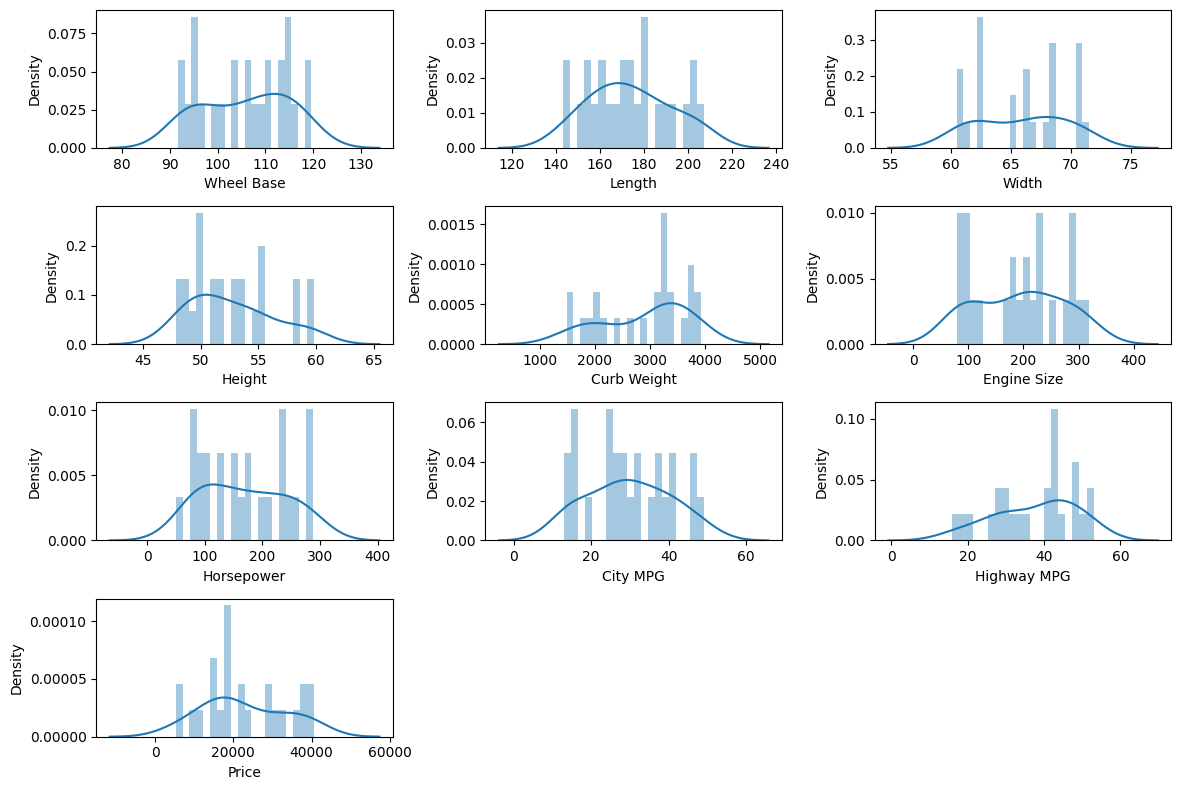

In [26]:
#univariate analysis
plt.figure(figsize=(12,8))
feature_list = car_df_num.columns

for i in range(len(feature_list)):
  plt.subplot(4,3,i+1)
  sns.distplot(car_df_num[feature_list[i]],kde=True,bins=20)
  plt.tight_layout()


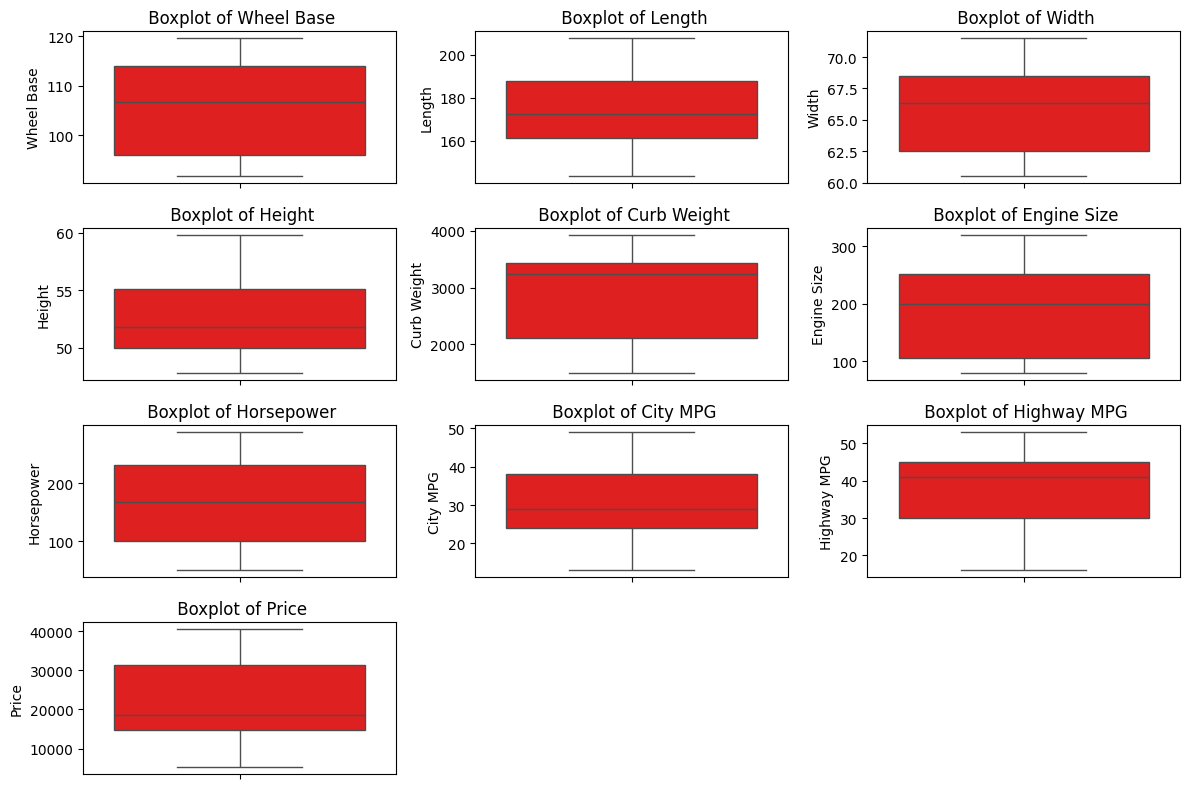

In [27]:
# for numerical values

plt.figure(figsize = (12,8))
feature_list = car_df_num.columns

for i in range(len(feature_list)):
  plt.subplot(4, 3, i + 1)
  sns.boxplot(car_df_num[feature_list[i]], color='r');
  plt.title(' Boxplot of {}'.format(feature_list[i]))
  plt.tight_layout()

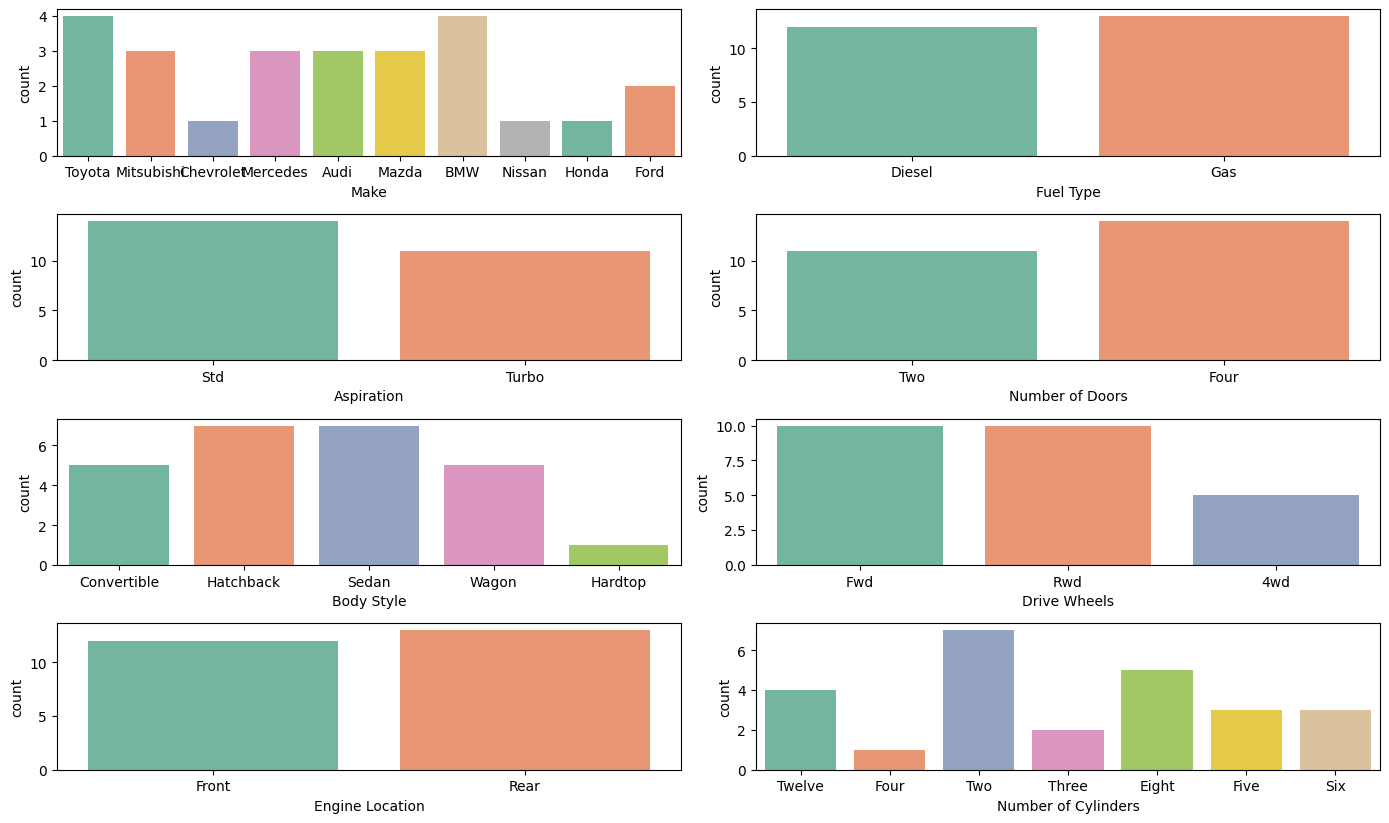

In [28]:
# for categorical values

plt.figure(figsize = (14,12))
feature_list = car_df_cat.columns
for i in range(len(feature_list)):
    plt.subplot(6, 2, i + 1)
    sns.countplot(x = car_df_cat[feature_list[i]], hue=car_df_cat[feature_list[i]], palette="Set2", legend=False)
    plt.tight_layout()

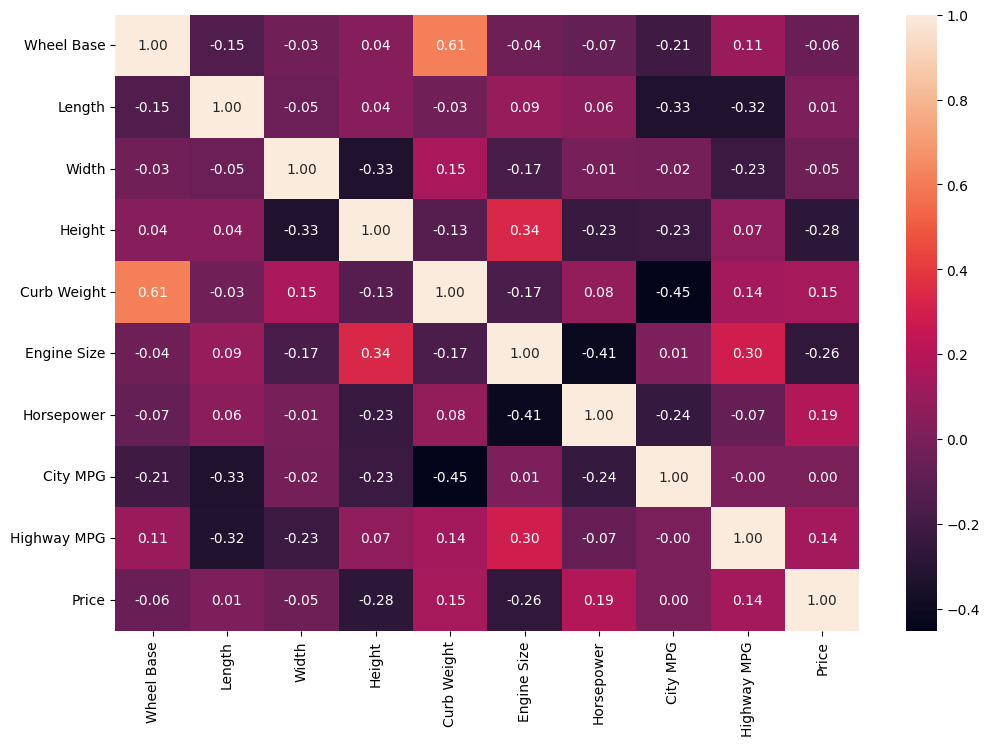

In [29]:
# checking correlation between variables
plt.figure(figsize=(12,8))
sns.heatmap(car_df_num.corr(),annot=True,fmt='.2f')
plt.show()

<Figure size 1200x800 with 0 Axes>

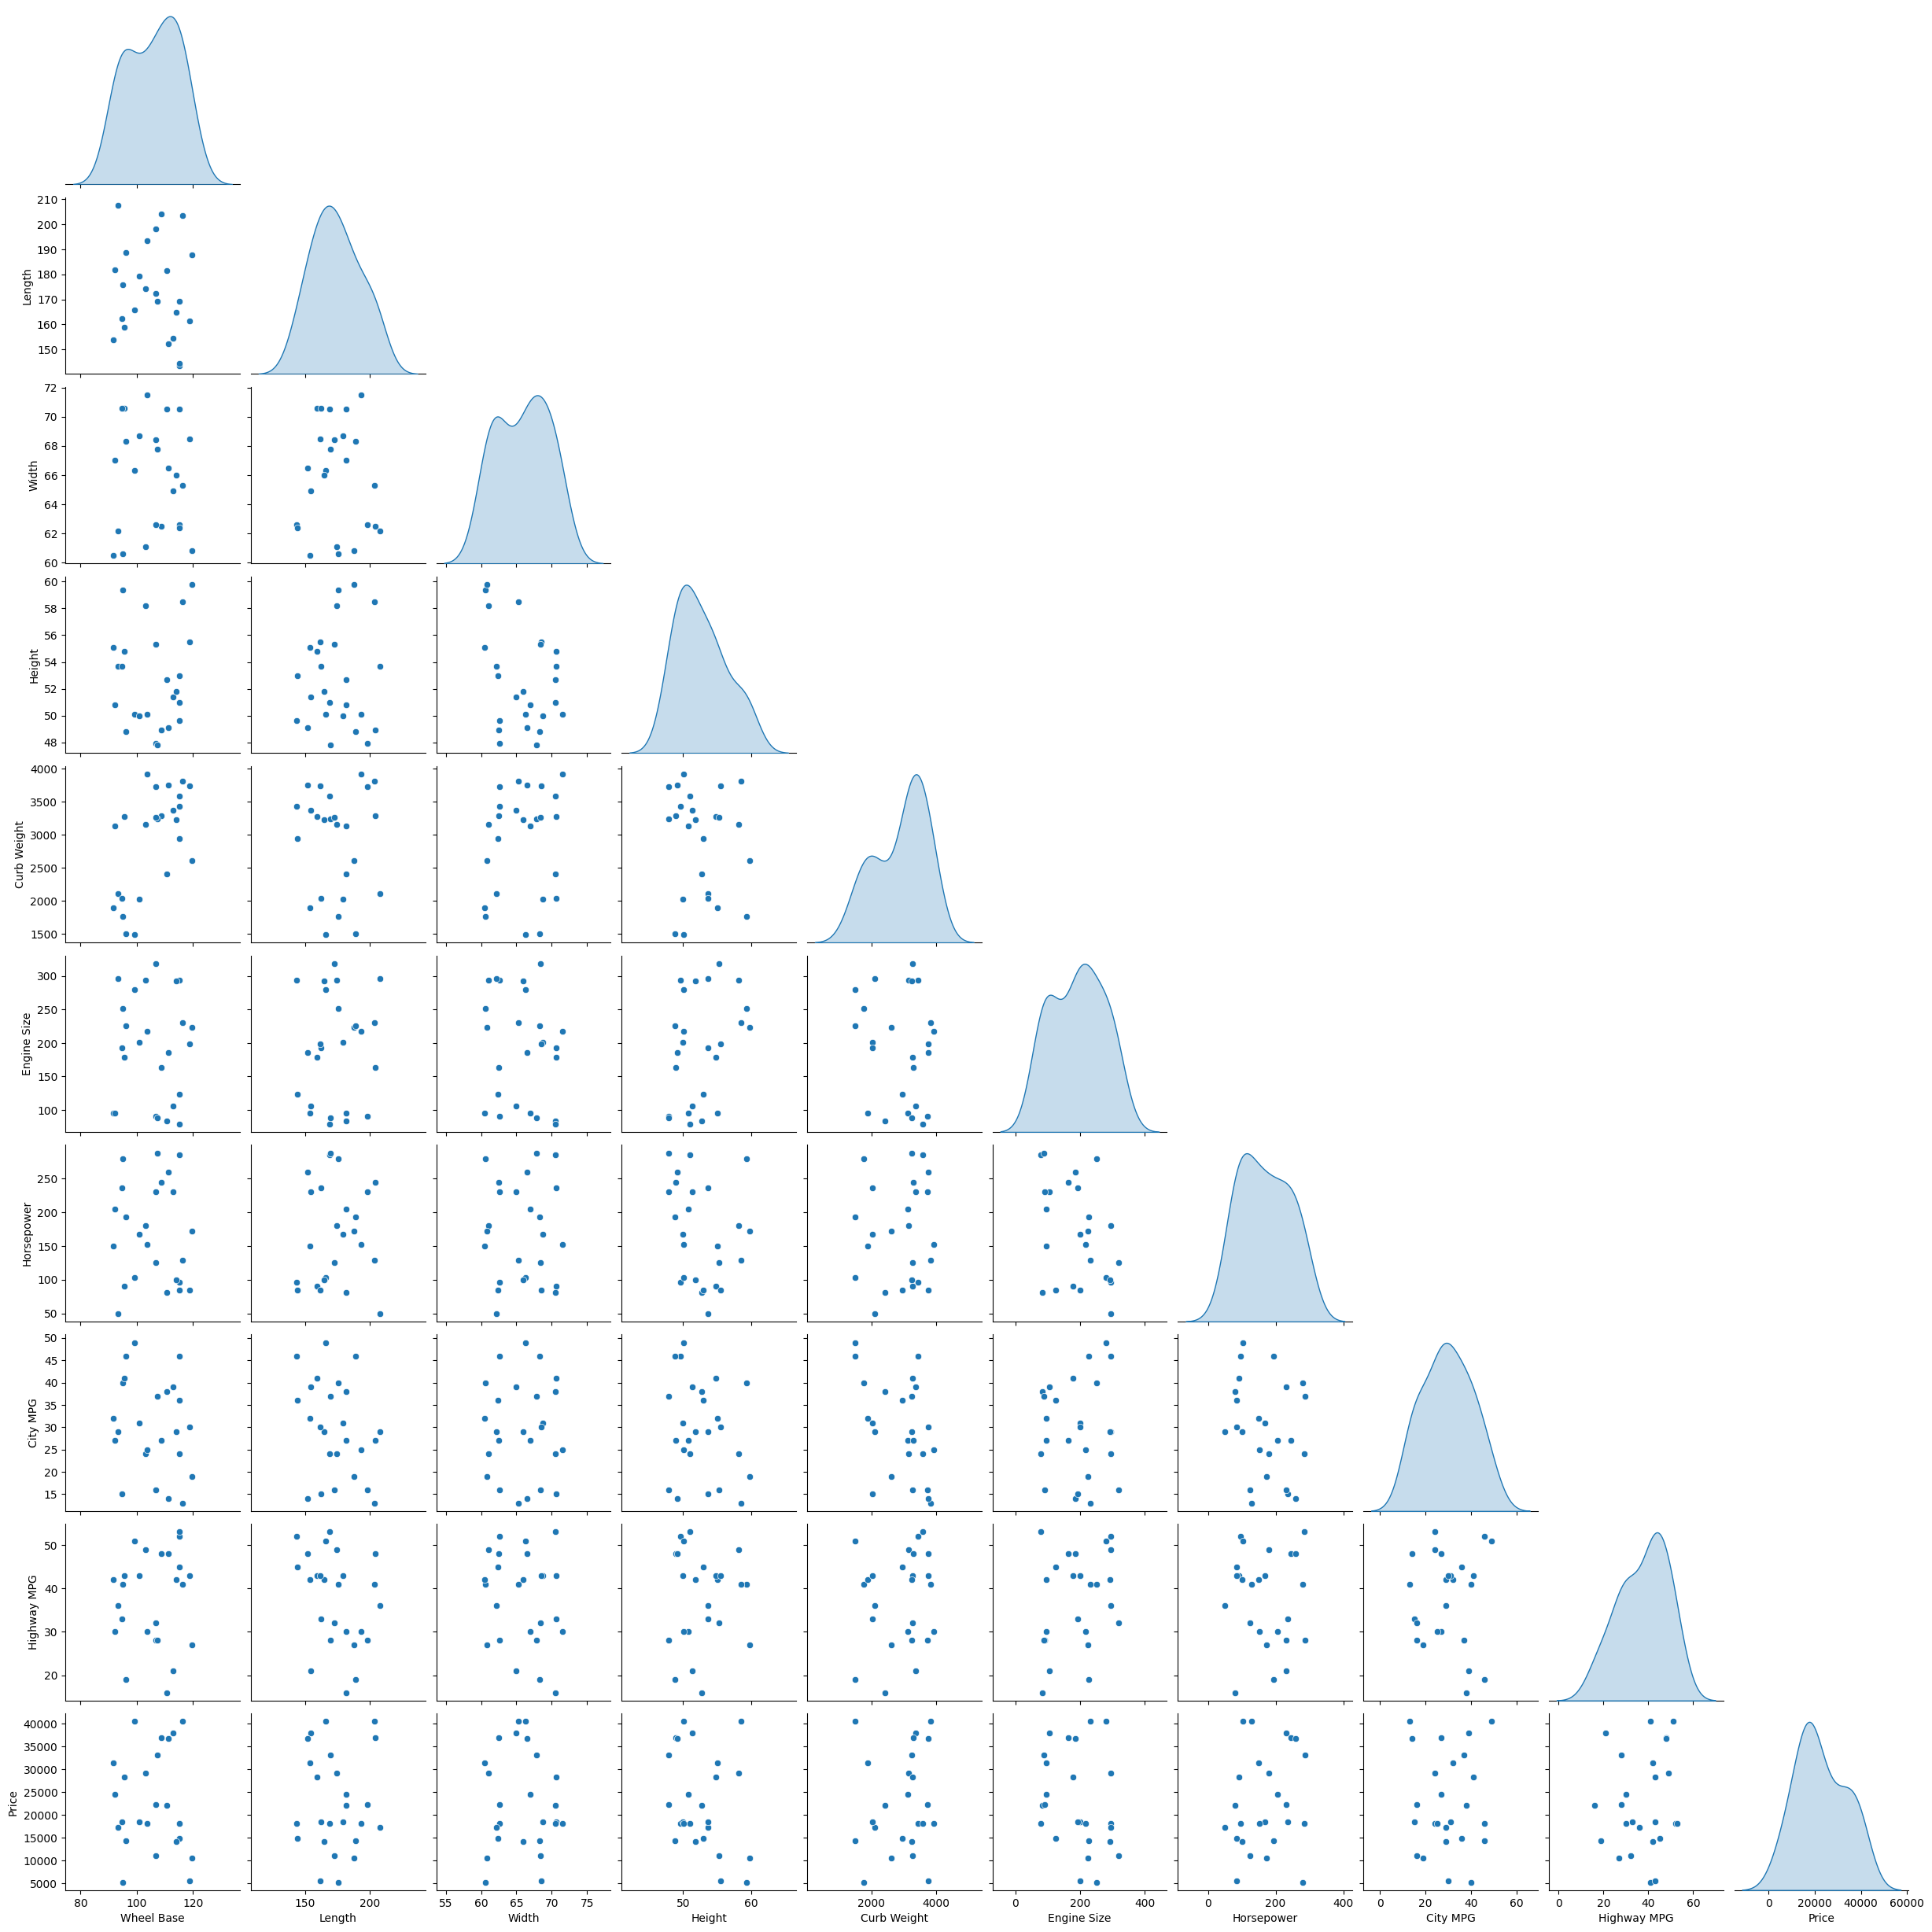

In [30]:
#pairplot
plt.figure(figsize=(12,8))
sns.pairplot(car_df_num,diag_kind='kde',corner=True)
plt.show()

In [38]:
#Q2.Summarize the data using descriptive statistics.

In [39]:
##getting more insights about the numerical variables
car_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Wheel Base,25.0,105.736,9.046403,91.7,96.0,106.8,113.9,119.6
Length,25.0,173.928,18.508523,143.4,161.4,172.4,187.8,207.6
Width,25.0,65.868,3.632804,60.5,62.5,66.3,68.5,71.5
Height,25.0,52.680,3.623534,47.8,50.0,51.8,55.1,59.8
Curb Weight,25.0,2907.720,777.650924,1488.0,2108.0,3231.0,3433.0,3922.0
Engine Size,25.0,192.360,79.342548,79.0,106.0,199.0,252.0,319.0
Horsepower,25.0,168.760,73.189981,50.0,100.0,168.0,231.0,288.0
City MPG,25.0,29.720,10.659581,13.0,24.0,29.0,38.0,49.0
Highway MPG,25.0,37.640,10.664896,16.0,30.0,41.0,45.0,53.0
Price,25.0,22684.920,10684.205266,5272.0,14838.0,18524.0,31393.0,40466.0


In [40]:
##getting more insights about the categroical variables
car_df_cat.describe().T


,count,unique,top,freq
Make,25,10,Toyota,4
Fuel Type,25,2,Gas,13
Aspiration,25,2,Std,14
Number of Doors,25,2,Four,14
Body Style,25,5,Hatchback,7
Drive Wheels,25,3,Fwd,10
Engine Location,25,2,Rear,13
Number of Cylinders,25,7,Two,7


In [50]:
#Q3.Identify the costliest car and the cheapest car by average price.
# Q3. Identify the costliest car and the cheapest car by average price.
temp_df = car_df.groupby(['Make'], as_index=False)['Price'].mean().sort_values(by='Price', ascending=False)
print(temp_df)

# Explicitly showing the costliest and cheapest
print("\n--- Summary ---")
print(f"Costliest Car (Highest Avg Price): {temp_df.iloc[0]['Make']} (${temp_df.iloc[0]['Price']:.2f})")
print(f"Cheapest Car (Lowest Avg Price): {temp_df.iloc[-1]['Make']} (${temp_df.iloc[-1]['Price']:.2f})")

         Make         Price
2   Chevrolet  40450.000000
7  Mitsubishi  30456.666667
0        Audi  27944.333333
9      Toyota  25292.500000
6    Mercedes  22832.000000
1         BMW  20076.750000
5       Mazda  18685.666667
8      Nissan  14838.000000
4       Honda  14109.000000
3        Ford   8246.500000

--- Summary ---
Costliest Car (Highest Avg Price): Chevrolet ($40450.00)
Cheapest Car (Lowest Avg Price): Ford ($8246.50)


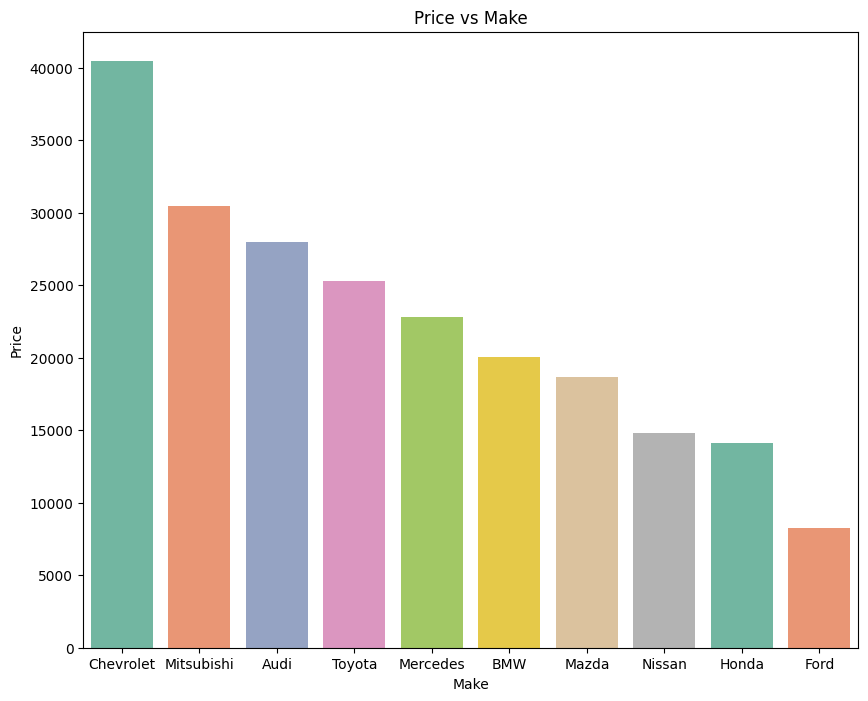

In [55]:
plt.figure(figsize=(10,8))

sns.barplot(data=temp_df, x="Make", y="Price",hue="Make", palette="Set2", legend=False)
plt.title("Price vs Make");

In [58]:
#Q4.Which fuel type car has the highest average price?

temp_df = car_df.groupby(['Fuel Type'],as_index=False)['Price'].mean().sort_values(by='Price',ascending=False)
temp_df

,Fuel Type,Price
1,Gas,24979.230769
0,Diesel,20199.416667


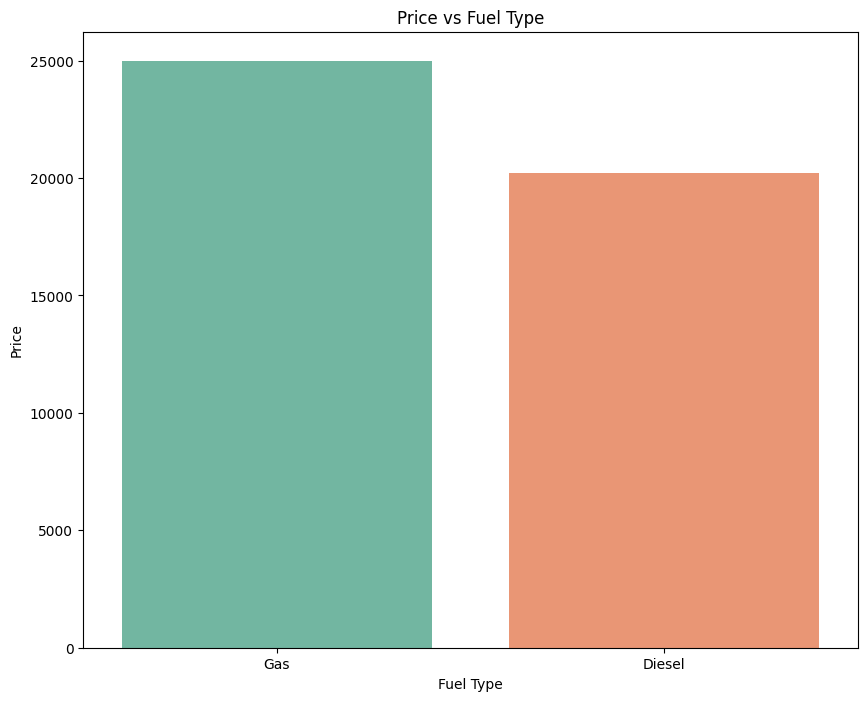

In [60]:
plt.figure(figsize=(10,8))

sns.barplot(data=temp_df, x="Fuel Type", y="Price",hue="Fuel Type", palette="Set2", legend=False)
plt.title("Price vs Fuel Type");

In [71]:
#Q5. For the given dataset, construct the following contingency table (take make as row variable)

data_crosstab = pd.crosstab(car_df['Make'],car_df['Fuel Type'],margins=False)
data_crosstab

Fuel Type,Diesel,Gas
Make,,
Audi,2,1
BMW,4,0
Chevrolet,0,1
Ford,0,2
Honda,0,1
Mazda,2,1
Mercedes,1,2
Mitsubishi,1,2
Nissan,0,1


In [75]:
data_crosstab = pd.crosstab(car_df['Make'],car_df['Body Style'],margins=False)
data_crosstab

Body Style,Convertible,Hardtop,Hatchback,Sedan,Wagon
Make,,,,,
Audi,1,0,0,1,1
BMW,1,1,1,0,1
Chevrolet,0,0,1,0,0
Ford,0,0,0,0,2
Honda,0,0,0,1,0
Mazda,0,0,2,1,0
Mercedes,0,0,1,2,0
Mitsubishi,1,0,1,0,1
Nissan,0,0,0,1,0


In [77]:
data_crosstab = pd.crosstab(car_df['Make'],car_df['Number of Cylinders'],margins=False)
data_crosstab

Number of Cylinders,Eight,Five,Four,Six,Three,Twelve,Two
Make,,,,,,,
Audi,1,1,0,1,0,0,0
BMW,2,0,0,0,0,1,1
Chevrolet,0,0,0,0,0,0,1
Ford,0,0,0,1,0,0,1
Honda,0,0,0,0,1,0,0
Mazda,1,1,0,0,0,0,1
Mercedes,0,1,0,1,0,0,1
Mitsubishi,0,0,1,0,1,1,0
Nissan,0,0,0,0,0,0,1


In [81]:
#Q6. What is the probability that a randomly selected car will be a BMW?

data1 = car_df['Make'].value_counts()['BMW']
data2 = car_df['Make'].count().sum()
probability = data1/data2
print('Probability of selecting car as BMW :', probability)

Probability of selecting car as BMW : 0.16


In [83]:
#Q7.What is the probability that a randomly selected car will be an Audi?

data1= car_df['Make'].value_counts()['Audi']
data2= car_df['Make'].count().sum()
probability = data1/data2
print('Probability of selecting car as Audi :', probability)


Probability of selecting car as Audi : 0.12


In [84]:

#Q8.Form the null and alternate hypothesis to test whether the price of Gas cars is significantly different from that of Diesel  Cars
#ANSWE : Null Hypotheis : states that there is no difference between the average price of Gas and Diesel Cars.

#Alternative Hypothesis : states that there is a difference between the average price of Gas and Diesel Cars.

#Ho: μ(Gas) - μ(Diesel) = 0

#H1: μ(Gas) - μ(Diesel) != 0

In [85]:
#Q9. Form the null and alternate hypothesis and find the p-value.At 0.05 level of significance, is the price of gas cars significantly different from that of diesel cars?

In [90]:
import scipy.stats as stats

group1 = car_df[car_df['Fuel Type']=='Gas']
group2 =car_df[car_df['Fuel Type']=='Diesel']

t_stat,p_value = stats.ttest_ind(group1['Price'],group2['Price'])
print('t-statistic:',t_stat)
print('p-value:',p_value)
#check
if p_value < 0.05:
  print('Reject the null hypothesis')
else:
  print('Fail to reject the null hypothesis')

t-statistic: 1.1236308256408953
p-value: 0.27276131360711153
Fail to reject the null hypothesis


In [92]:
 #Q10. Suppose you randomly select a car from this dataset. What is the probability that it is a 'Luxury Car' ?
# (consider BMW, Mercedes and Audi as a luxary car under the column Make )

car_df['Make'].value_counts()




,count
Make,
Toyota,4
BMW,4
Mitsubishi,3
Mercedes,3
Mazda,3
Audi,3
Ford,2
Chevrolet,1
Nissan,1


In [100]:
total_car = car_df['Make'].value_counts().sum()
selected = car_df[(car_df['Make']=='BMW') | (car_df['Make']=='Mercedes')| (car_df['Make']=='Audi')]
selected_total = selected.shape[0] #number of rows of luxury cars

In [101]:
req_probability = selected_total/total_car
print('Probability of selecting a luxury car:',req_probability)

Probability of selecting a luxury car: 0.4


In [103]:

#Q11. You want to select a subset of three unique cars from the dataset to participate in a race. How many different ways can you arrange the cars in the race, considering their 'Make' as the criteria?
import itertools

car_makes=list(car_df['Make'].unique())

num_cars_to_select = 3

permutations = list(itertools.permutations(car_makes, num_cars_to_select))

num_arrangements = len(permutations)

print(f'Number of different ways to arrange 3 cars: { num_arrangements}')

Number of different ways to arrange 3 cars: 720


In [105]:
#Q12. If you randomly pick a car with 8 cylinders, what is the probability that BMW?
combined = pd.crosstab(car_df['Make'],car_df['Number of Cylinders'],margins=True)
combined

Number of Cylinders,Eight,Five,Four,Six,Three,Twelve,Two,All
Make,,,,,,,,
Audi,1,1,0,1,0,0,0,3
BMW,2,0,0,0,0,1,1,4
Chevrolet,0,0,0,0,0,0,1,1
Ford,0,0,0,1,0,0,1,2
Honda,0,0,0,0,1,0,0,1
Mazda,1,1,0,0,0,0,1,3
Mercedes,0,1,0,1,0,0,1,3
Mitsubishi,0,0,1,0,1,1,0,3
Nissan,0,0,0,0,0,0,1,1


In [108]:
req_probability= combined.iloc[1,0]/combined.iloc[10,0]
print(f'probability of it being a bMW is {req_probability}')

probability of it being a bMW is 0.4


In [112]:
# Q13. You are conducting a random survey by selecting 7 cars from the dataset. Calculate the probability that exactly 3 out of the 7 selected cars have 'Turbo' aspiration.
car_df['Aspiration'].value_counts()


,count
Aspiration,
Std,14
Turbo,11


In [116]:
turbo_num=car_df[car_df['Aspiration']=='Turbo'].shape[0]
total=car_df.shape[0]

p_turbo=turbo_num/total
p_turbo

0.44

In [117]:
import scipy.stats as stats

k = 3
n= 7
prob_turbo = stats.binom.pmf(k,n,p_turbo)
print(f'Thus the probability that exactly 3 out of 7 selected cars have turbo aspiration is',round(prob_turbo,2))


Thus the probability that exactly 3 out of 7 selected cars have turbo aspiration is 0.29
